# 01. Credit Risk Preprocess

loan 与信データを読み込み、学習用の前処理を行います。  
このノートブックでは、特殊値の整理、特殊値フラグの追加、特徴量作成を行い、最終的に `df_train.parquet` と `df_test.parquet` を保存します。


## ライブラリインポート


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")


## データロード


In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
load = False

if load:
    accepted_usecols = [
        "loan_amnt",
        "issue_d",
        "dti",
        "zip_code",
        "addr_state",
        "emp_length",
        "policy_code",
        "fico_range_low",
        "fico_range_high",
        "title",
        "purpose",
    ]

    accepted_df = pd.read_csv(
        DATA_DIR / "accepted_2007_to_2018Q4.csv.gz",
        usecols=accepted_usecols,
        low_memory=False,
    )

    rejected_df = pd.read_csv(
        DATA_DIR / "rejected_2007_to_2018Q4.csv.gz",
        low_memory=False,
    )

    display(accepted_df.head(5))
    display(rejected_df.head(5))
else:
    print("skip data load section; set load=True to rebuild df_base from raw csv files.")


skip data load section; set load=True to rebuild df_base from raw csv files.


# データの結合


In [3]:
if load:
    final_common_columns = [
        "requested_loan_amount",
        "application_date",
        "dti",
        "state",
        "employment_length",
        "FICO_risk_score",
        "is_rejected",
    ]


In [4]:
if load:
    cutoff_date = pd.Timestamp("2013-06-30")

    accepted_issue_date = pd.to_datetime(accepted_df["issue_d"], format="%b-%Y", errors="coerce")
    rejected_application_date = pd.to_datetime(rejected_df["Application Date"], errors="coerce")

    accepted_filtered_df = accepted_df.loc[accepted_issue_date <= cutoff_date].copy()
    rejected_filtered_df = rejected_df.loc[rejected_application_date <= cutoff_date].copy()

    print("accepted original shape:", accepted_df.shape)
    print("accepted filtered shape:", accepted_filtered_df.shape)
    print("rejected original shape:", rejected_df.shape)
    print("rejected filtered shape:", rejected_filtered_df.shape)


In [5]:
if load:
    accepted_filtered_df["FICO_risk_score"] = (
        accepted_filtered_df["fico_range_low"] + accepted_filtered_df["fico_range_high"]
    ) / 2

    rejected_filtered_df["FICO_risk_score"] = rejected_filtered_df["Risk_Score"]

    display(accepted_filtered_df[["FICO_risk_score"]].head(5))
    display(rejected_filtered_df[["FICO_risk_score"]].head(5))


In [6]:
if load:
    accepted_filtered_df["requested_loan_amount"] = accepted_filtered_df["loan_amnt"]
    rejected_filtered_df["requested_loan_amount"] = rejected_filtered_df["Amount Requested"]

    display(accepted_filtered_df[["requested_loan_amount"]].head(5))
    display(rejected_filtered_df[["requested_loan_amount"]].head(5))


In [7]:
if load:
    accepted_filtered_df["dti"] = accepted_filtered_df["dti"]
    rejected_filtered_df["dti"] = rejected_filtered_df["Debt-To-Income Ratio"].str.replace("%", "", regex=False).astype(float)

    display(accepted_filtered_df[["dti"]].head(5))
    display(rejected_filtered_df[["dti"]].head(5))


In [8]:
if load:
    accepted_filtered_df["state"] = accepted_filtered_df["addr_state"]
    rejected_filtered_df["state"] = rejected_filtered_df["State"]

    display(accepted_filtered_df[["state"]].head(5))
    display(rejected_filtered_df[["state"]].head(5))

    print("accepted state unique count:", accepted_filtered_df["state"].nunique(dropna=True))
    print(sorted(accepted_filtered_df["state"].dropna().unique().tolist()))

    print("rejected state unique count:", rejected_filtered_df["state"].nunique(dropna=True))
    print(sorted(rejected_filtered_df["state"].dropna().unique().tolist()))


In [9]:
if load:
    accepted_filtered_df["employment_length"] = accepted_filtered_df["emp_length"]
    rejected_filtered_df["employment_length"] = rejected_filtered_df["Employment Length"]

    display(accepted_filtered_df[["employment_length"]].head(5))
    display(rejected_filtered_df[["employment_length"]].head(5))

    print("accepted employment_length unique count:", accepted_filtered_df["employment_length"].nunique(dropna=True))
    print(sorted(accepted_filtered_df["employment_length"].dropna().unique().tolist()))

    print("rejected employment_length unique count:", rejected_filtered_df["employment_length"].nunique(dropna=True))
    print(sorted(rejected_filtered_df["employment_length"].dropna().unique().tolist()))


In [10]:
if load:
    accepted_filtered_df["application_date"] = accepted_issue_date.loc[accepted_filtered_df.index]
    rejected_filtered_df["application_date"] = rejected_application_date.loc[rejected_filtered_df.index]

    accepted_filtered_df["is_rejected"] = 0
    rejected_filtered_df["is_rejected"] = 1

    accepted_common_df = accepted_filtered_df[final_common_columns].copy()
    rejected_common_df = rejected_filtered_df[final_common_columns].copy()

    df_base = pd.concat([accepted_common_df, rejected_common_df], axis=0, ignore_index=True)

    print("accepted common shape:", accepted_common_df.shape)
    print("rejected common shape:", rejected_common_df.shape)
    print("concatenated df shape:", df_base.shape)
    display(df_base.head(5))


# 

In [11]:
OUTPUT_PATH = DATA_DIR / "df_loan_base.parquet"

if load:
    df_base.to_parquet(OUTPUT_PATH, index=False)
    print("saved:", OUTPUT_PATH, df_base.shape)


In [12]:
loded_from_parquet = True
if loded_from_parquet:
    df_base = pd.read_parquet(DATA_DIR / "df_loan_base.parquet")

df_transformed = df_base.copy()

accepted_transformed_df = df_transformed.loc[df_transformed["is_rejected"] == 0].copy()
rejected_transformed_df = df_transformed.loc[df_transformed["is_rejected"] == 1].copy()

print("accepted transformed shape:", accepted_transformed_df.shape)
print("rejected transformed shape:", rejected_transformed_df.shape)
print("df_transformed shape:", df_transformed.shape)


accepted transformed shape: (149276, 7)
rejected transformed shape: (1059406, 7)
df_transformed shape: (1208682, 7)


# Data Overview

## 列の分類


In [13]:
target_col = "is_rejected"

all_columns = df_base.columns.to_list()

id_cols = []
datetime_cols = ["application_date"]

num_columns = ["requested_loan_amount", "dti", "FICO_risk_score"]
cat_columns = ["state",]
flag_columns = []
ordinal_columns = ["employment_length"]
drop_columns = []

base_feature_columns = [
    col for col in df_base.columns
    if col not in {target_col, *id_cols, *datetime_cols, *drop_columns}
]
feature_columns = base_feature_columns.copy()

print("target column:", target_col)
print("feature count:", len(base_feature_columns))
print("feature columns:", base_feature_columns)
print("num_columns:", num_columns)
print("cat_columns:", cat_columns)
print("datetime_cols:", datetime_cols)


target column: is_rejected
feature count: 5
feature columns: ['requested_loan_amount', 'dti', 'state', 'employment_length', 'FICO_risk_score']
num_columns: ['requested_loan_amount', 'dti', 'FICO_risk_score']
cat_columns: ['state']
datetime_cols: ['application_date']


In [14]:
df_transformed[feature_columns + [target_col]].describe().T


,count,mean,std,min,25%,50%,75%,max
requested_loan_amount,1208682.0,13312.987111,10484.879660,0.0,5000.00,10000.00,20000.00,1400000.00
dti,1208682.0,648.757140,47970.400169,-1.0,6.76,16.72,29.21,50000031.49
FICO_risk_score,1181207.0,609.562033,166.505194,0.0,595.00,656.00,692.00,850.00
is_rejected,1208682.0,0.876497,0.329014,0.0,1.00,1.00,1.00,1.00


In [15]:
missing_ratio_df = pd.DataFrame({
    "missing_count": df_transformed[feature_columns].isna().sum(),
    "missing_ratio_pct": df_transformed[feature_columns].isna().mean().mul(100),
})

missing_ratio_df = (
    missing_ratio_df
    .rename_axis("feature")
    .reset_index()
    .sort_values("missing_ratio_pct", ascending=False)
)

missing_ratio_df["missing_ratio_pct"] = missing_ratio_df["missing_ratio_pct"].round(2)

missing_ratio_df


,feature,missing_count,missing_ratio_pct
4,FICO_risk_score,27475,2.27
3,employment_length,16579,1.37
2,state,21,0.00
0,requested_loan_amount,0,0.00
1,dti,0,0.00


## 分布確認


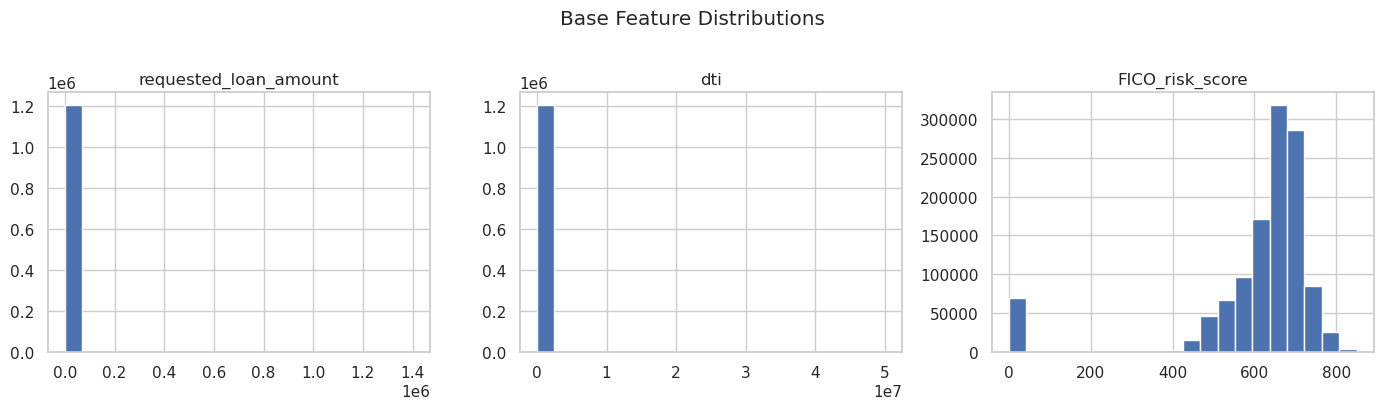

In [16]:
plot_num_columns = num_columns
axes = df_transformed[plot_num_columns].hist(figsize=(14, 4), bins=20, layout=(1, len(plot_num_columns)))
plt.suptitle("Base Feature Distributions", y=1.02)
plt.tight_layout()


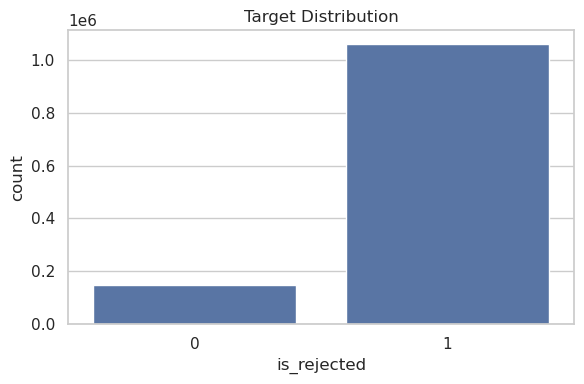

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_transformed, x=target_col)
plt.title("Target Distribution")
plt.tight_layout()


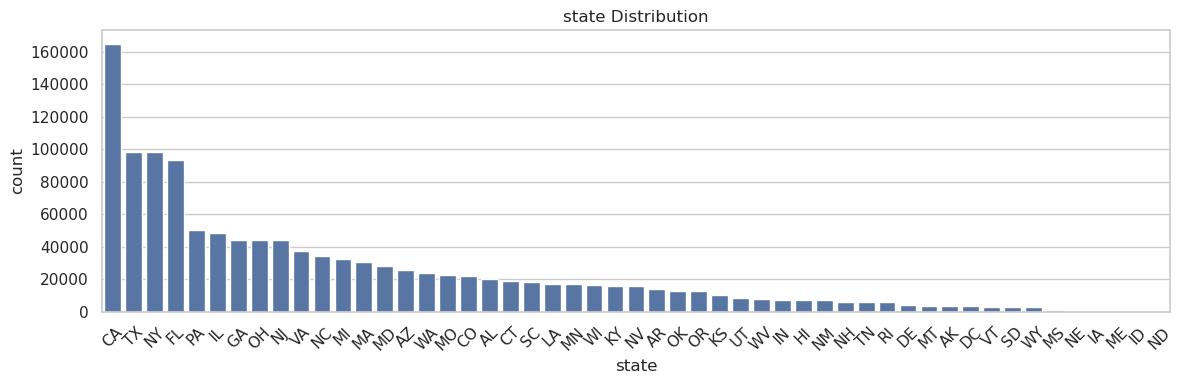

In [18]:
if cat_columns:
    fig, axes = plt.subplots(len(cat_columns), 1, figsize=(12, 4 * len(cat_columns)))
    if len(cat_columns) == 1:
        axes = [axes]

    for ax, col in zip(axes, cat_columns):
        order = df_transformed[col].value_counts().index.tolist()
        sns.countplot(data=df_transformed, x=col, order=order, ax=ax)
        ax.set_title(f"{col} Distribution")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()


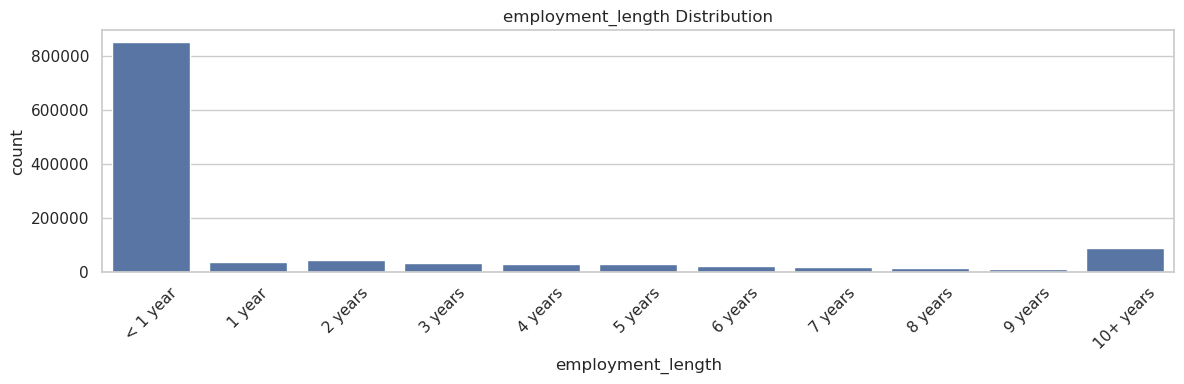

In [19]:
if ordinal_columns:
    fig, axes = plt.subplots(len(ordinal_columns), 1, figsize=(12, 4 * len(ordinal_columns)))
    if len(ordinal_columns) == 1:
        axes = [axes]

    employment_length_order = [
        "< 1 year",
        "1 year",
        "2 years",
        "3 years",
        "4 years",
        "5 years",
        "6 years",
        "7 years",
        "8 years",
        "9 years",
        "10+ years",
    ]

    for ax, col in zip(axes, ordinal_columns):
        if col == "employment_length":
            order = [value for value in employment_length_order if value in df_transformed[col].dropna().unique()]
        else:
            order = df_transformed[col].value_counts().index.tolist()

        sns.countplot(data=df_transformed, x=col, order=order, ax=ax)
        ax.set_title(f"{col} Distribution")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()


# データクレンジング


## 不正値処理

- `requested_loan_amount`: 0 以上のみ許容
- `dti`: 0 以上 1000 未満のみ許容
- `FICO_risk_score`: 0 以上 1000 未満のみ許容


In [20]:
constraint_rules = {
    "requested_loan_amount": lambda s: s >= 0,
    "dti": lambda s: (s >= 0) & (s < 1000),
    "FICO_risk_score": lambda s: (s >= 0) & (s < 1000),
}


constraint_cleaning_summary = []
for col, rule in constraint_rules.items():
    invalid_mask = df_transformed[col].notna() & ~rule(df_transformed[col])
    invalid_count = int(invalid_mask.sum())

    df_transformed.loc[invalid_mask, col] = np.nan

    constraint_cleaning_summary.append({
        "column": col,
        "invalid_to_nan_count": invalid_count,
        "invalid_to_nan_ratio": invalid_count / len(df_transformed),
    })

pd.DataFrame(constraint_cleaning_summary)


,column,invalid_to_nan_count,invalid_to_nan_ratio
0,requested_loan_amount,0,0.000000
1,dti,30458,0.025199
2,FICO_risk_score,0,0.000000


## 欠損確認


In [21]:
missing_summary = pd.DataFrame({
    "missing_count": df_transformed.isnull().sum(),
    "missing_ratio": df_transformed.isnull().mean(),
})

missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)


,missing_count,missing_ratio
dti,30458,0.025199
FICO_risk_score,27475,0.022731
employment_length,16579,0.013717
state,21,0.000017


In [22]:
print("remaining missing values in df_transformed:", int(df_transformed.isnull().sum().sum()))


remaining missing values in df_transformed: 74533


# 特徴量成形


## 対数スケーリング


In [23]:
skew_threshold = 5.0

skew_base_columns = [
    col for col in num_columns
    if col in df_transformed.columns and col != target_col
]

skew_summary = (
    df_transformed[skew_base_columns]
    .agg(["skew", "min", "max"])
    .T.rename(columns={"skew": "skewness", "min": "min_value", "max": "max_value"})
    .sort_values("skewness", key=lambda s: s.abs(), ascending=False)
)
skew_summary["abs_skewness"] = skew_summary["skewness"].abs()
skew_summary["recommended_transform"] = np.select(
    [
        (skew_summary["skewness"] >= skew_threshold) & (skew_summary["min_value"] >= 0),
        skew_summary["abs_skewness"] >= skew_threshold,
    ],
    ["log1p", "consider_other_transform"],
    default="keep_as_is",
)

skewed_cols = skew_summary.query("abs_skewness >= @skew_threshold").index.tolist()
log_candidate_cols = skew_summary.query(
    "skewness >= @skew_threshold and min_value >= 0"
).index.tolist()

skew_summary.head(30)


,skewness,min_value,max_value,abs_skewness,recommended_transform
dti,10.257498,0.0,999.5,10.257498,log1p
requested_loan_amount,4.726340,0.0,1400000.0,4.726340,keep_as_is
FICO_risk_score,-2.788128,0.0,850.0,2.788128,keep_as_is


In [24]:
available_log_cols = [col for col in log_candidate_cols if col in df_transformed.columns]

for col in available_log_cols:
    df_transformed[f"{col}_log1p"] = np.log1p(df_transformed[col].clip(lower=0))

log_output_columns = [f"{col}_log1p" for col in available_log_cols]
num_columns = sorted(set(num_columns + log_output_columns) - set(available_log_cols))
drop_columns = sorted(set(drop_columns + available_log_cols))

print(f"歪度しきい値: {skew_threshold}")
print("歪んだ列候補:", skewed_cols)
print("log1p 候補列:", log_candidate_cols)
print("dropped original cols:", available_log_cols)
print("log feature count:", len(log_output_columns))


歪度しきい値: 5.0
歪んだ列候補: ['dti']
log1p 候補列: ['dti']
dropped original cols: ['dti']
log feature count: 1


## エンコーディング

In [25]:
state_dummy_df = pd.get_dummies(df_transformed["state"], prefix="state", dummy_na=False, dtype=int)
df_transformed = pd.concat([df_transformed, state_dummy_df], axis=1)

state_flag_columns = state_dummy_df.columns.tolist()
flag_columns = sorted(set(flag_columns + state_flag_columns))
cat_columns = sorted(set(cat_columns) - {"state"})
drop_columns = sorted(set(drop_columns + ["state"]))

print("state one-hot columns:", state_flag_columns)
print("flag feature count:", len(flag_columns))
print("cat columns:", cat_columns)
print("drop columns:", drop_columns)


state one-hot columns: ['state_AK', 'state_AL', 'state_AR', 'state_AZ', 'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN', 'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME', 'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC', 'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI', 'state_SC', 'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VA', 'state_VT', 'state_WA', 'state_WI', 'state_WV', 'state_WY']
flag feature count: 51
cat columns: []
drop columns: ['dti', 'state']


## 順序特徴量の成形

In [26]:
employment_length_mapping = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10,
}

employment_length_encoded_col = "employment_length_ordinal"
df_transformed[employment_length_encoded_col] = df_transformed["employment_length"].map(employment_length_mapping)

ordinal_columns = sorted(set(ordinal_columns + [employment_length_encoded_col]) - {"employment_length"})
drop_columns = sorted(set(drop_columns + ["employment_length"]))

print("employment_length mapping:", employment_length_mapping)
print("ordinal columns:", ordinal_columns)
print("drop columns:", drop_columns)
print("mapped unique values:", sorted(df_transformed[employment_length_encoded_col].dropna().unique().tolist()))


employment_length mapping: {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}
ordinal columns: ['employment_length_ordinal']
drop columns: ['dti', 'employment_length', 'state']
mapped unique values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


## 欠損処理

In [27]:
row_count_before_dropna = len(df_transformed)
df_transformed = df_transformed.dropna().reset_index(drop=True)
row_count_after_dropna = len(df_transformed)
dropped_row_count = row_count_before_dropna - row_count_after_dropna

print("row_count_before_dropna:", row_count_before_dropna)
print("row_count_after_dropna:", row_count_after_dropna)
print("dropped_row_count:", dropped_row_count)
print("dropped_row_ratio:", round(dropped_row_count / row_count_before_dropna, 4))


row_count_before_dropna: 1208682
row_count_after_dropna: 1156280
dropped_row_count: 52402
dropped_row_ratio: 0.0434


# 確認


In [28]:
manual_drop_columns = [
    "credit_history_length",
    "delinquency_trade_sum_log1p",
    "months_since_first_trade",
    "nr_inquiries_in_last_6_months_log1p",
]

drop_columns = sorted(set(drop_columns + manual_drop_columns))
num_columns = sorted(set(num_columns) - set(manual_drop_columns))

print("manually dropped columns:", manual_drop_columns)


manually dropped columns: ['credit_history_length', 'delinquency_trade_sum_log1p', 'months_since_first_trade', 'nr_inquiries_in_last_6_months_log1p']


In [29]:
model_feature_cols = sorted(
    set(num_columns + cat_columns + flag_columns + ordinal_columns) - set(drop_columns)
)
feature_columns = model_feature_cols.copy()

print("target_col:", target_col)
print("num feature count:", len(num_columns))
print("flag feature count:", len(flag_columns))
print("cat feature count:", len(cat_columns))
print("ordinal feature count:", len(ordinal_columns))
print("final feature count:", len(model_feature_cols))
print("missing in df_transformed:", int(df_transformed[model_feature_cols].isnull().sum().sum()))

df_transformed[model_feature_cols + [target_col]].head()


target_col: is_rejected
num feature count: 3
flag feature count: 51
cat feature count: 0
ordinal feature count: 1
final feature count: 55
missing in df_transformed: 0


,FICO_risk_score,dti_log1p,employment_length_ordinal,requested_loan_amount,state_AK,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,is_rejected
0,737.0,3.355153,10.0,5000.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,742.0,0.693147,0.0,2500.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,737.0,2.274186,10.0,2400.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,692.0,3.044522,10.0,10000.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,697.0,2.941276,1.0,3000.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# データ保存


In [30]:
OUTPUT_DIR = BASE_DIR / "data"
TRANSFORMED_OUTPUT_PATH = OUTPUT_DIR / "df_loan_transformed.parquet"

output_columns = model_feature_cols + [target_col]
transformed_output_df = df_transformed[output_columns].copy()

transformed_output_df.to_parquet(TRANSFORMED_OUTPUT_PATH, index=False)

print("saved:", TRANSFORMED_OUTPUT_PATH, transformed_output_df.shape)


saved: /home/kohei/WorkSpace/blog/01.Counterfactual_Analysis/data/df_loan_transformed.parquet (1156280, 56)
